/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/nibabel/optpkg.py:104: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  pkg = __import__(name, fromlist=fromlist)
/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



    The plotting functions break depending on versions of torch and monai, and backend for nii loading.
    They are still useful, but become heavily distorted if the nii loading backend is not set to nibabel. 
    If you see distorted plots, try setting the environment variable:
    


/home/emastr/github/aipek_task_2026/notebooks/../src/plots.py:130: RuntimeWarning: All-NaN slice encountered
  np.nanmax(data_np[idx[0]-thicknesses[0]:idx[0]+thicknesses[0], :, :], axis=0),
/home/emastr/github/aipek_task_2026/notebooks/../src/plots.py:131: RuntimeWarning: All-NaN slice encountered
  np.nanmax(data_np[:, idx[1]-thicknesses[1]:idx[1]+thicknesses[1], :], axis=1),
/home/emastr/github/aipek_task_2026/notebooks/../src/plots.py:132: RuntimeWarning: All-NaN slice encountered
  np.nanmax(data_np[:, :, idx[2]-thicknesses[2]:idx[2]+thicknesses[2]], axis=2)


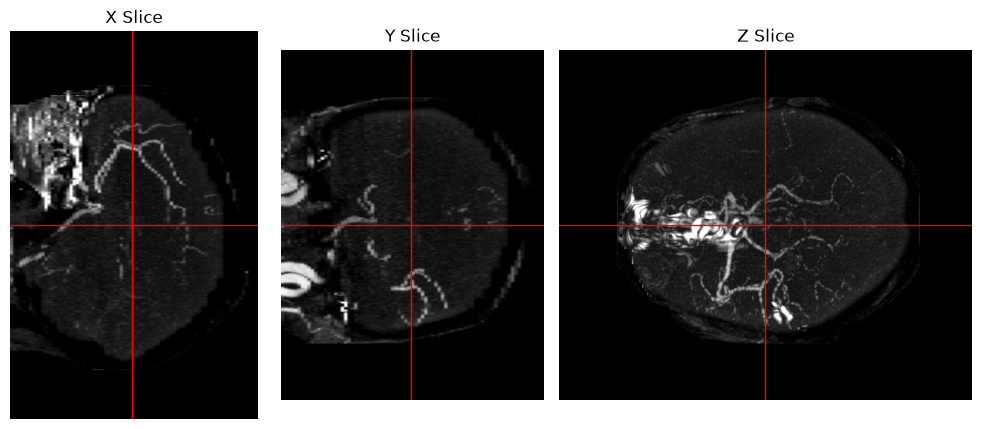

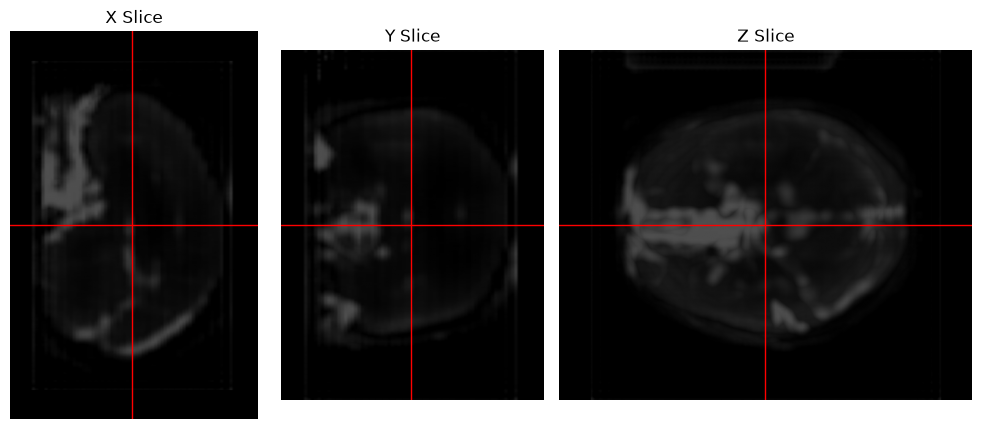

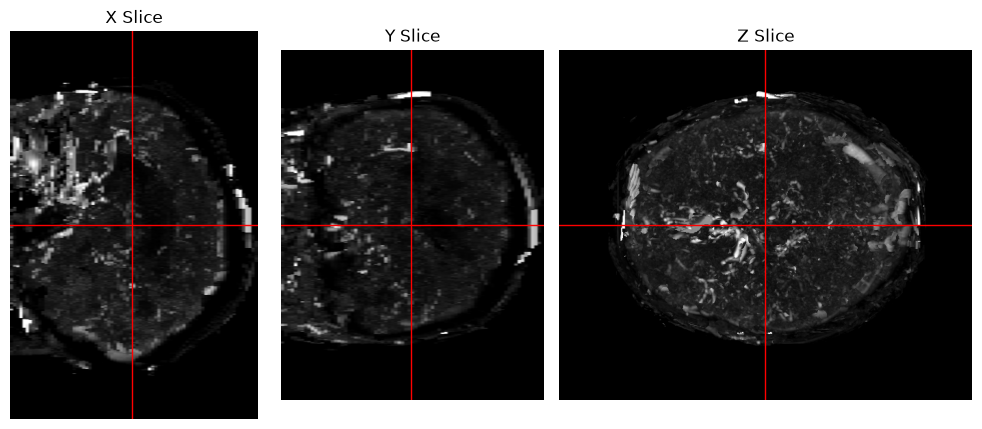

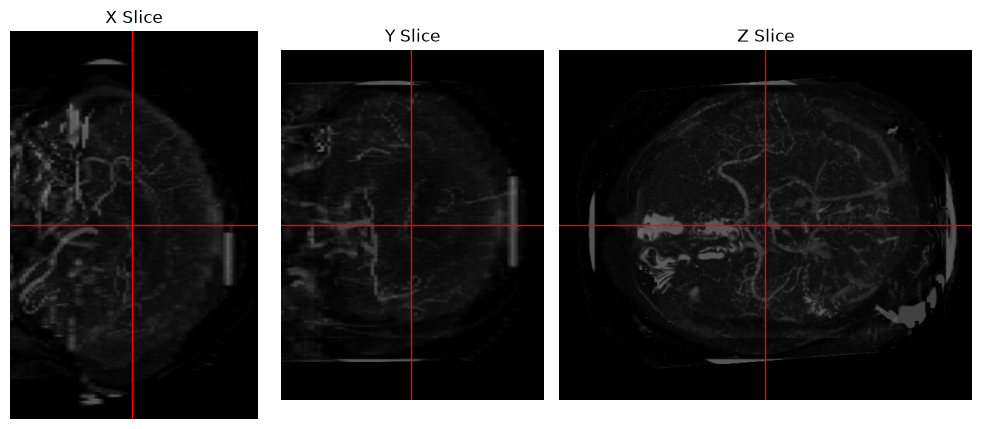

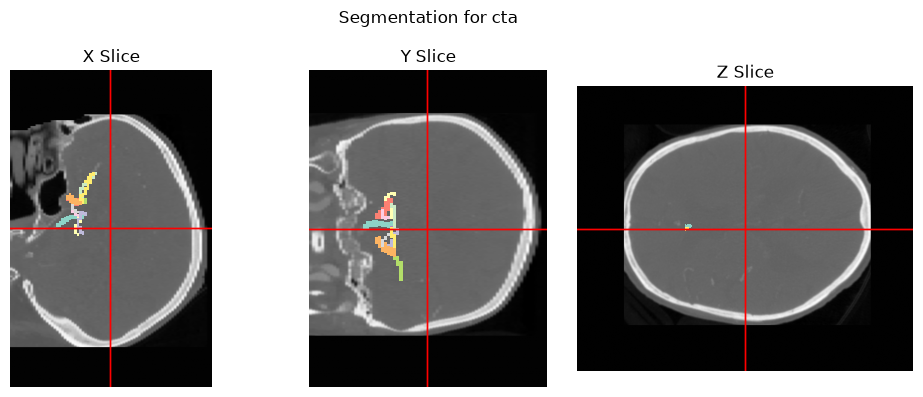

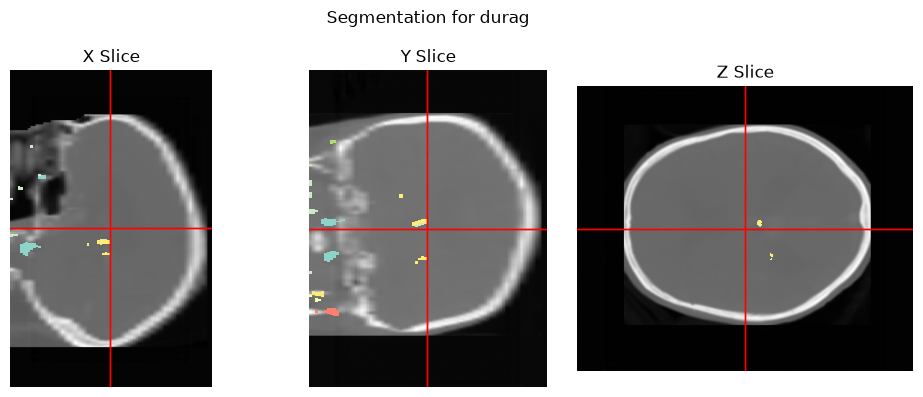

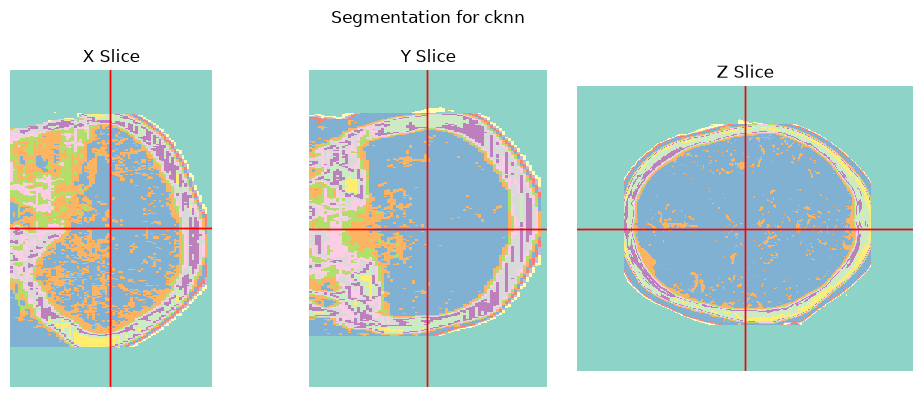

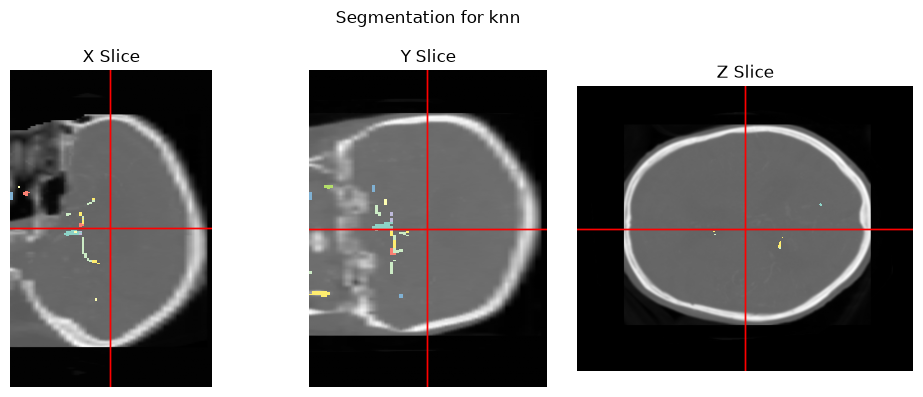

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from src.processing import CONSTANTS
from src.plots import plot_cta_and_segmentation, plot_from_path

pred_path = f"../{CONSTANTS.NORM_PRED_PATH}"
pred_path_norm = f"../{CONSTANTS.NORM_PRED_PATH}"
data_path_norm = f"../{CONSTANTS.NORM_DATA_PATH_VAL_OUT}"

case_channel = {"cta": ("0001","0001"),
                "durag": ("0001","0001"),
                #"ncct": ("0000","0000"), 
                "cknn": ("0001","0001"),
                "knn": ("0001","0001"),
                }


id_no = 10
id_no = str(id_no).zfill(4)

# First print the vessel structures
for case, channel in case_channel.items():
    
    if case == "cta":
        path = f"{data_path_norm}/case_{id_no}_{channel[0]}.nii.gz"
    else:
        path = f"{pred_path_norm}/images_norm_{case}/case_{id_no}_{channel[0]}.nii.gz"
    fig = plot_from_path(
        path=path,
        slices = (0.5, 0.5, 0.5),
        thicknesses = (20, 20, 20),
        cmap = "gray",
        vmin=-1,
        vmax=1
    )
    plt.tight_layout()
    plt.gcf().savefig(f"../figures/vessel_{id_no}_{case}.png", dpi=300)

# Then print the secmentation results
for case, channel in case_channel.items():    
    input_case_path = f"{pred_path}/images_{case}/case_{id_no}_{channel[0]}.nii.gz"
    fig = plot_cta_and_segmentation(
        input_case_path=input_case_path,
        prediction_case_path=f"{pred_path}/segment_{case}/case_{id_no}_{channel[1]}.nii.gz",
        slices = (0.5, 0.5, 0.5),
        thickness = (1, 1, 1),
        figsize=(10, 4)
    )
    plt.suptitle(f"Segmentation for {case}")
    plt.tight_layout()
    plt.gcf().savefig(f"../figures/segmentation_{id_no}_{case}.png", dpi=300)